In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from mlxtend.plotting import plot_decision_regions
from sklearn.model_selection import train_test_split
from sklearn.datasets import make_circles

In [2]:
np.random.seed(42)

In [3]:
X,y=make_circles(n_samples=500,factor=0.1,noise=0.35,random_state=42)

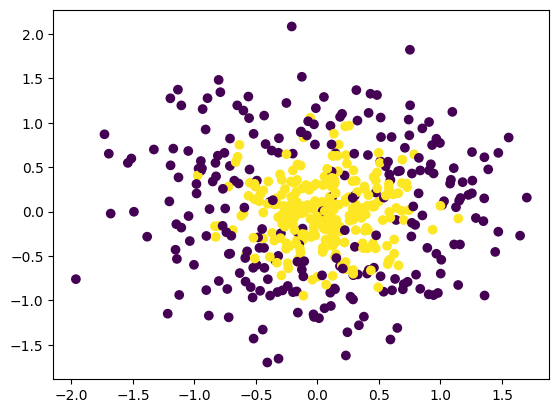

In [4]:
plt.scatter(X[:,0],X[:,1],c=y)


In [9]:
from sklearn.ensemble import AdaBoostClassifier
from sklearn.model_selection import cross_val_score
abc=AdaBoostClassifier(n_estimators=1500,learning_rate=0.1)
np.mean(cross_val_score(abc,X,y,scoring='accuracy',cv=10))

np.float64(0.8240000000000001)

In [10]:
abc.fit(X,y)

,estimator,None
,n_estimators,1500
,learning_rate,0.1
,algorithm,'deprecated'
,random_state,None


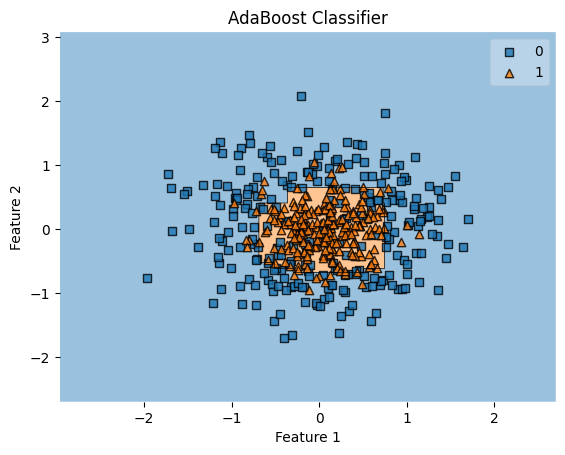

In [11]:
from mlxtend.plotting import plot_decision_regions

plot_decision_regions(X, y, clf=abc)

plt.title("AdaBoost Classifier")
plt.xlabel("Feature 1")
plt.ylabel("Feature 2")
plt.show()

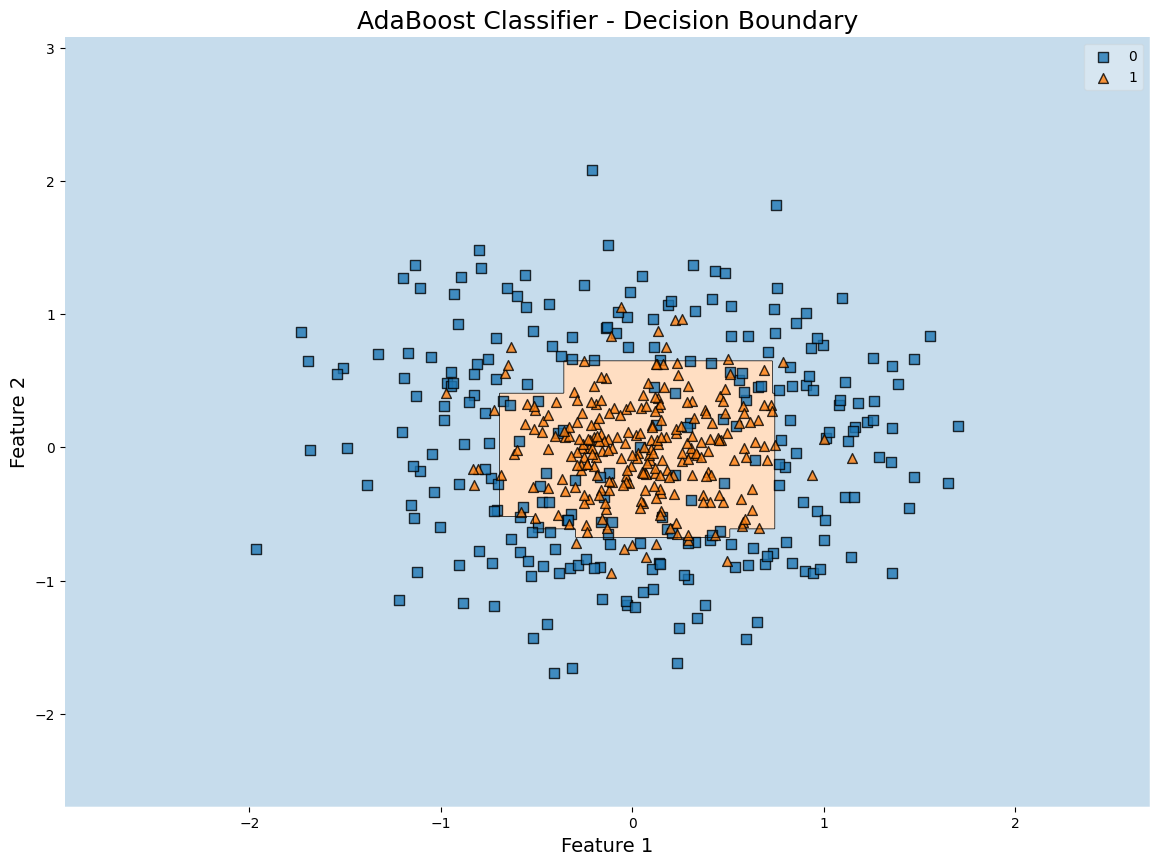

In [12]:
plt.figure(figsize=(14, 10))

plot_decision_regions(
    X, y,
    clf=abc,
    scatter_kwargs={'s': 50, 'edgecolor': 'black'},
    contourf_kwargs={'alpha': 0.25}
)

plt.title("AdaBoost Classifier - Decision Boundary", fontsize=18)
plt.xlabel("Feature 1", fontsize=14)
plt.ylabel("Feature 2", fontsize=14)

plt.show()

In [13]:
from sklearn.model_selection import GridSearchCV

grid = dict()
grid['n_estimators'] = [10, 50, 100, 500]
grid['learning_rate'] = [0.0001, 0.001, 0.01, 0.1, 1.0]
grid['algorithm'] = ['SAMME', 'SAMME.R']


grid_search = GridSearchCV(estimator=AdaBoostClassifier(), param_grid=grid, n_jobs=-1, cv=10, scoring='accuracy')
# execute the grid search
grid_result = grid_search.fit(X, y)
# summarize the best score and configuration
print("Best: %f using %s" % (grid_result.best_score_, grid_result.best_params_))

C:\Users\USER\anaconda3\envs\Booksenv\Lib\site-packages\sklearn\model_selection\_validation.py:516: FitFailedWarning: 
200 fits failed out of a total of 400.
The score on these train-test partitions for these parameters will be set to nan.
If these failures are not expected, you can try to debug them by setting error_score='raise'.

Below are more details about the failures:
--------------------------------------------------------------------------------
200 fits failed with the following error:
Traceback (most recent call last):
  File "C:\Users\USER\anaconda3\envs\Booksenv\Lib\site-packages\sklearn\model_selection\_validation.py", line 859, in _fit_and_score
    estimator.fit(X_train, y_train, **fit_params)
    ~~~~~~~~~~~~~^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "C:\Users\USER\anaconda3\envs\Booksenv\Lib\site-packages\sklearn\base.py", line 1358, in wrapper
    estimator._validate_params()
    ~~~~~~~~~~~~~~~~~~~~~~~~~~^^
  File "C:\Users\USER\anaconda3\envs\Booksenv\Lib\site-packag

Best: 0.832000 using {'algorithm': 'SAMME', 'learning_rate': 0.1, 'n_estimators': 500}
